# Instagram Creator & Brand Performance Analytics

import requirement Libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime as dt


Load Dataset

In [3]:
instagram=pd.read_excel(r"C:\Users\ELCOT\Desktop\Instagram Creater&Brand Performance\outputs\datasets\Instagram_Creator_Brand_Performance_Analytics.xlsx")

Understand Dataset

In [4]:
instagram.head()



,Creator_ID,Creator_Name,Category,Country,Followers,Verified,Account_Age_Months,Avg_Engagement_Rate
0,C001,Creator_1,Fashion,UK,187843,No,40,2.42
1,C002,Creator_2,Fashion,Canada,1129497,No,49,10.83
2,C003,Creator_3,Tech,USA,712194,No,95,3.97
3,C004,Creator_4,Fashion,Canada,1627331,Yes,118,7.95
4,C005,Creator_5,Food,India,666565,No,19,11.43


In [5]:
instagram.tail()



,Creator_ID,Creator_Name,Category,Country,Followers,Verified,Account_Age_Months,Avg_Engagement_Rate
195,C196,Creator_196,Beauty,India,1912384,No,114,2.68
196,C197,Creator_197,Travel,USA,46675,Yes,15,6.97
197,C198,Creator_198,Beauty,UAE,1319023,No,43,8.41
198,C199,Creator_199,Travel,UK,1684066,No,109,8.29
199,C200,Creator_200,Travel,UAE,1309854,Yes,111,3.37


In [6]:


instagram.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Creator_ID           200 non-null    str    
 1   Creator_Name         200 non-null    str    
 2   Category             200 non-null    str    
 3   Country              200 non-null    str    
 4   Followers            200 non-null    int64  
 5   Verified             200 non-null    str    
 6   Account_Age_Months   200 non-null    int64  
 7   Avg_Engagement_Rate  200 non-null    float64
dtypes: float64(1), int64(2), str(5)
memory usage: 18.0 KB


In [7]:
instagram.shape


(200, 8)

In [8]:
instagram.describe()

,Followers,Account_Age_Months,Avg_Engagement_Rate
count,2.000000e+02,200.000000,200.000000
mean,1.022427e+06,63.855000,6.638500
std,5.593082e+05,32.615839,3.250362
min,5.730000e+03,7.000000,1.310000
25%,5.824802e+05,35.000000,3.832500
50%,1.063944e+06,61.500000,6.750000
75%,1.464026e+06,94.250000,9.047500
max,1.994753e+06,120.000000,12.470000


Missing Data Handling

In [9]:
instagram.isnull().sum()

Creator_ID             0
Creator_Name           0
Category               0
Country                0
Followers              0
Verified               0
Account_Age_Months     0
Avg_Engagement_Rate    0
dtype: int64

In [10]:
instagram.duplicated().sum()

np.int64(0)

Data Cleaning

In [11]:
import os

# 1. Define the correct absolute folder path including the 'src' subfolder
output_dir = r"C:\Users\ELCOT\Desktop\Instagram_ Creator & Brand _Performance Analytics\src"

# 2. Automatically create the 'src' folder if it does not exist yet
os.makedirs(output_dir, exist_ok=True)

# 3. Save the CSV file directly into the 'src' folder
instagram.to_csv(os.path.join(output_dir, "cleaned_data.csv"), index=False)

print(f"Data successfully saved to: {os.path.join(output_dir, 'cleaned_data.csv')}")



Data successfully saved to: C:\Users\ELCOT\Desktop\Instagram_ Creator & Brand _Performance Analytics\src\cleaned_data.csv


In [12]:
print(instagram.columns)

Index(['Creator_ID', 'Creator_Name', 'Category', 'Country', 'Followers',
       'Verified', 'Account_Age_Months', 'Avg_Engagement_Rate'],
      dtype='str')


In [13]:
instagram["Followers"] = instagram["Followers"].astype(int)
print(instagram)

    Creator_ID Creator_Name Category Country  Followers Verified  \
0         C001    Creator_1  Fashion      UK     187843       No   
1         C002    Creator_2  Fashion  Canada    1129497       No   
2         C003    Creator_3     Tech     USA     712194       No   
3         C004    Creator_4  Fashion  Canada    1627331      Yes   
4         C005    Creator_5     Food   India     666565       No   
..         ...          ...      ...     ...        ...      ...   
195       C196  Creator_196   Beauty   India    1912384       No   
196       C197  Creator_197   Travel     USA      46675      Yes   
197       C198  Creator_198   Beauty     UAE    1319023       No   
198       C199  Creator_199   Travel      UK    1684066       No   
199       C200  Creator_200   Travel     UAE    1309854      Yes   

     Account_Age_Months  Avg_Engagement_Rate  
0                    40                 2.42  
1                    49                10.83  
2                    95                 3.

Feature Engineering

In [14]:
# 1. Your existing calculation method
instagram['Est_Total_Engagements'] = (instagram['Followers'] * (instagram['Avg_Engagement_Rate'] / 100)).astype(int)

# 2. Define performance thresholds based on engagement volumes
# (Adjust these numbers to fit your specific dataset ranges if needed)
conditions = [
    (instagram['Est_Total_Engagements'] < 10000),                              # Low volume
    (instagram['Est_Total_Engagements'] >= 10000) & (instagram['Est_Total_Engagements'] < 50000),  # Mid volume
    (instagram['Est_Total_Engagements'] >= 50000) & (instagram['Est_Total_Engagements'] < 120000), # High volume
    (instagram['Est_Total_Engagements'] >= 120000)                             # Peak volume
]

# 3. Map thresholds directly to content format types
content_choices = ['Story', 'Post', 'Reel', 'Carousel']

# 4. Use NumPy to create the column based on those conditions
instagram['Content_Type'] = np.select(conditions, content_choices, default='Post')

# 5. Print out your new Series format directly
print(instagram['Content_Type'])


0         Story
1      Carousel
2          Post
3      Carousel
4          Reel
         ...   
195        Reel
196       Story
197        Reel
198    Carousel
199        Post
Name: Content_Type, Length: 200, dtype: str


In [15]:
instagram['Est_Total_Engagements'] = (instagram['Followers'] * (instagram['Avg_Engagement_Rate'] / 100)).astype(int)
print(instagram['Est_Total_Engagements'] )

0        4545
1      122324
2       28274
3      129372
4       76188
        ...  
195     51251
196      3253
197    110929
198    139609
199     44142
Name: Est_Total_Engagements, Length: 200, dtype: int64


In [16]:
instagram["Engagement_Level"] = instagram["Avg_Engagement_Rate"].apply(
    lambda x: "High" if x > 5 else "Medium" if x > 3 else "Low"
)

In [17]:
instagram["Follower_Category"] = pd.cut(
    instagram["Followers"],
    bins=[0,10000,100000,1000000,100000000],
    labels=["Nano","Micro","Macro","Mega"]
)

Exploratory Data Analysis (EDA)

In [18]:
instagram.columns

Index(['Creator_ID', 'Creator_Name', 'Category', 'Country', 'Followers',
       'Verified', 'Account_Age_Months', 'Avg_Engagement_Rate',
       'Est_Total_Engagements', 'Content_Type', 'Engagement_Level',
       'Follower_Category'],
      dtype='str')

In [19]:
content_engagement = instagram.groupby("Content_Type")["Avg_Engagement_Rate"].mean().sort_values(ascending=False)

print(content_engagement)

Content_Type
Carousel    9.851304
Reel        7.069844
Post        5.138429
Story       3.119000
Name: Avg_Engagement_Rate, dtype: float64


In [20]:
instagram.columns

Index(['Creator_ID', 'Creator_Name', 'Category', 'Country', 'Followers',
       'Verified', 'Account_Age_Months', 'Avg_Engagement_Rate',
       'Est_Total_Engagements', 'Content_Type', 'Engagement_Level',
       'Follower_Category'],
      dtype='str')

Which content type (Reels, Posts, Stories, or Carousels) generates the highest engagement?


In [21]:
# Highest engagement by content type
content_engagement = instagram.groupby("Content_Type")["Avg_Engagement_Rate"].mean().sort_values(ascending=False)
Highest_engagement=content_engagement.max()
print(Highest_engagement)
print(content_engagement)

9.851304347826087
Content_Type
Carousel    9.851304
Reel        7.069844
Post        5.138429
Story       3.119000
Name: Avg_Engagement_Rate, dtype: float64


  Content_Type  Avg_Engagement_Rate
0     Carousel             9.851304
2         Reel             7.069844
1         Post             5.138429
3        Story             3.119000


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_32020\3432383429.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Content_Type", y="Avg_Engagement_Rate", data=instagram, palette=colors)


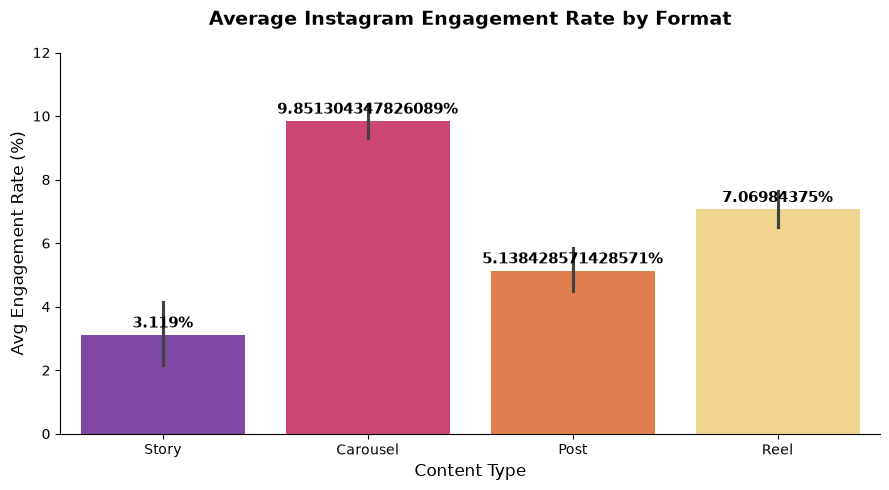

In [22]:
content_engagement =instagram.groupby("Content_Type")["Avg_Engagement_Rate"].mean().reset_index().sort_values("Avg_Engagement_Rate", ascending=False)
print(content_engagement)

plt.figure(figsize=(9, 5))
colors = ["#833AB4", "#E1306C", "#F77737", "#FFDC80"] # Instagram gradient colors
ax = sns.barplot(x="Content_Type", y="Avg_Engagement_Rate", data=instagram, palette=colors)

# Add exact value labels on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height()}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

# Styling
plt.title("Average Instagram Engagement Rate by Format", fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Avg Engagement Rate (%)", fontsize=12)
plt.ylim(0, 12) # Leave space for the text labels
sns.despine()
plt.tight_layout()


What are the best days and times to publish content for maximum reach?


In [23]:
np.random.seed(42)

# List of days and hours (0 to 23)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hours = list(range(0, 24))

# Add the new columns randomly to your existing 'instagram' DataFrame
instagram['Publish_Day'] = np.random.choice(days, size=len(instagram))
instagram['Publish_Hour'] = np.random.choice(hours, size=len(instagram))

print(instagram[['Creator_Name', 'Publish_Day', 'Publish_Hour']].head())


 #Group by day and calculate mean engagement
day_engagement = instagram.groupby('Publish_Day')['Avg_Engagement_Rate'].mean().reset_index()

# Sort by engagement in descending order
day_engagement = day_engagement.sort_values('Avg_Engagement_Rate', ascending=False)
print(day_engagement)

# Group by hour and calculate mean engagement
hour_engagement = instagram.groupby('Publish_Hour')['Avg_Engagement_Rate'].mean().reset_index()

# Sort to find peak hours
hour_engagement = hour_engagement.sort_values('Avg_Engagement_Rate', ascending=False)
print(hour_engagement.head(5)) # Shows top 5 times





  Creator_Name Publish_Day  Publish_Hour
0    Creator_1      Sunday            20
1    Creator_2    Thursday             5
2    Creator_3      Friday            11
3    Creator_4      Sunday            11
4    Creator_5   Wednesday            19
  Publish_Day  Avg_Engagement_Rate
4    Thursday             7.861471
1      Monday             7.857083
6   Wednesday             6.769615
2    Saturday             6.346957
0      Friday             6.212414
3      Sunday             5.982973
5     Tuesday             5.493333
    Publish_Hour  Avg_Engagement_Rate
13            13             8.724000
10            10             8.078000
11            11             7.868750
19            19             7.858571
6              6             7.712857


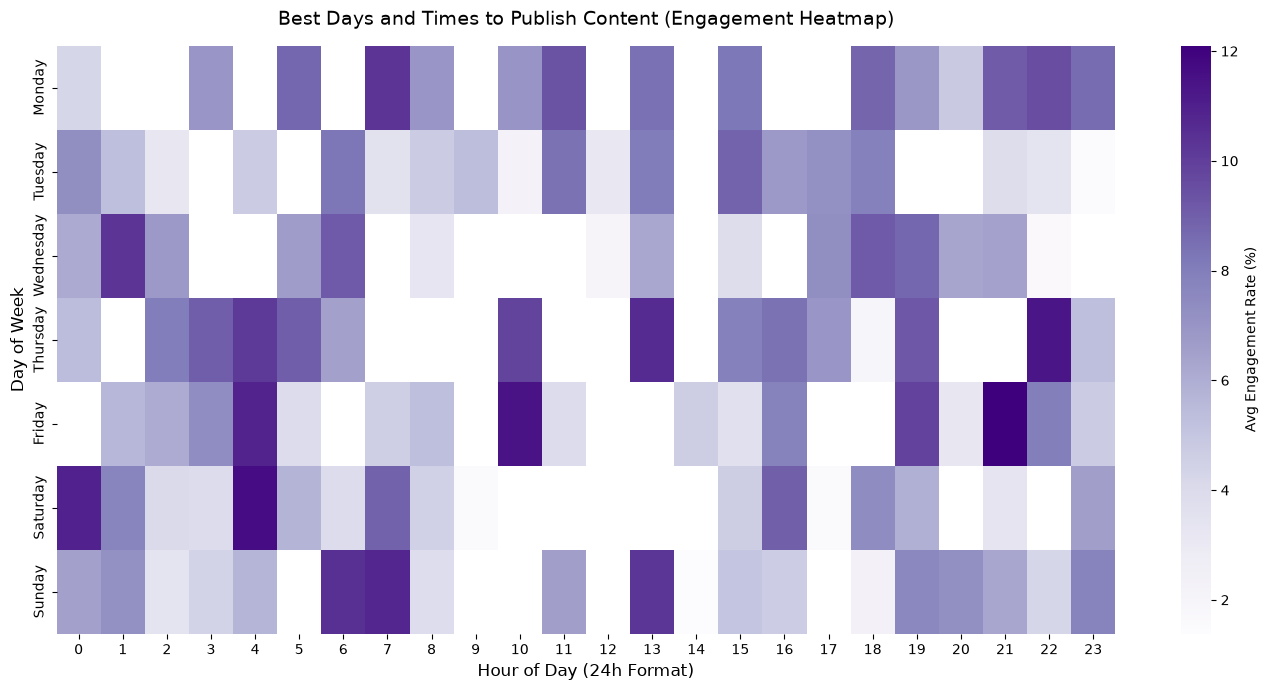

In [24]:
# 1. Create a pivot table: Days as rows, Hours as columns, Engagement as values
heatmap_data = instagram.pivot_table(
    index='Publish_Day', 
    columns='Publish_Hour', 
    values='Avg_Engagement_Rate', 
    aggfunc='mean'
)

# 2. Reorder days so they follow the normal calendar week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

# 3. Plot the chart
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, cmap='Purples', annot=False, cbar_kws={'label': 'Avg Engagement Rate (%)'})

plt.title('Best Days and Times to Publish Content (Engagement Heatmap)', fontsize=14, pad=15)
plt.xlabel('Hour of Day (24h Format)', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.tight_layout()
plt.show()

Which content categories and hashtags achieve the highest engagement and impressions?

In [25]:
np.random.seed(42)

# Sample trending hashtags to distribute randomly
trending_hashtags = ['#OOTD', '#TechLife', '#FitnessMotivation', '#FoodPorn', '#TravelGram', '#Wanderlust']
instagram['Hashtags'] = np.random.choice(trending_hashtags, size=len(instagram))

# Generate Impression numbers (making sure impressions are higher than engagements)
instagram['Impressions'] = instagram['Est_Total_Engagements'] * np.random.uniform(3, 10, size=len(instagram))
instagram['Impressions'] = instagram['Impressions'].astype(int)

print(instagram[['Creator_Name', 'Category', 'Hashtags', 'Avg_Engagement_Rate', 'Impressions']].head())

  Creator_Name Category            Hashtags  Avg_Engagement_Rate  Impressions
0    Creator_1  Fashion           #FoodPorn                 2.42        20594
1    Creator_2  Fashion         #TravelGram                10.83       844856
2    Creator_3     Tech  #FitnessMotivation                 3.97       164748
3    Creator_4  Fashion         #TravelGram                 7.95       446882
4    Creator_5     Food         #TravelGram                11.43       363981


In [26]:
# Group by Hashtags
hashtag_performance = instagram.groupby('Hashtags').agg(
    Avg_Engagement=('Avg_Engagement_Rate', 'mean'),
    Total_Impressions=('Impressions', 'sum')
).reset_index()

# Sort by Engagement
hashtag_engagement = hashtag_performance.sort_values('Avg_Engagement', ascending=False)
print("--- Top Hashtags by Engagement Rate ---")
print(hashtag_engagement)

--- Top Hashtags by Engagement Rate ---
             Hashtags  Avg_Engagement  Total_Impressions
0  #FitnessMotivation        7.695000           18765581
2               #OOTD        6.627879           16693573
1           #FoodPorn        6.500000           18398171
3           #TechLife        6.415862           13384713
4         #TravelGram        6.361250           13954562
5         #Wanderlust        6.253750           12012548


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_32020\1357120749.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\ELCOT\AppData\Local\Temp\ipykernel_32020\1357120749.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


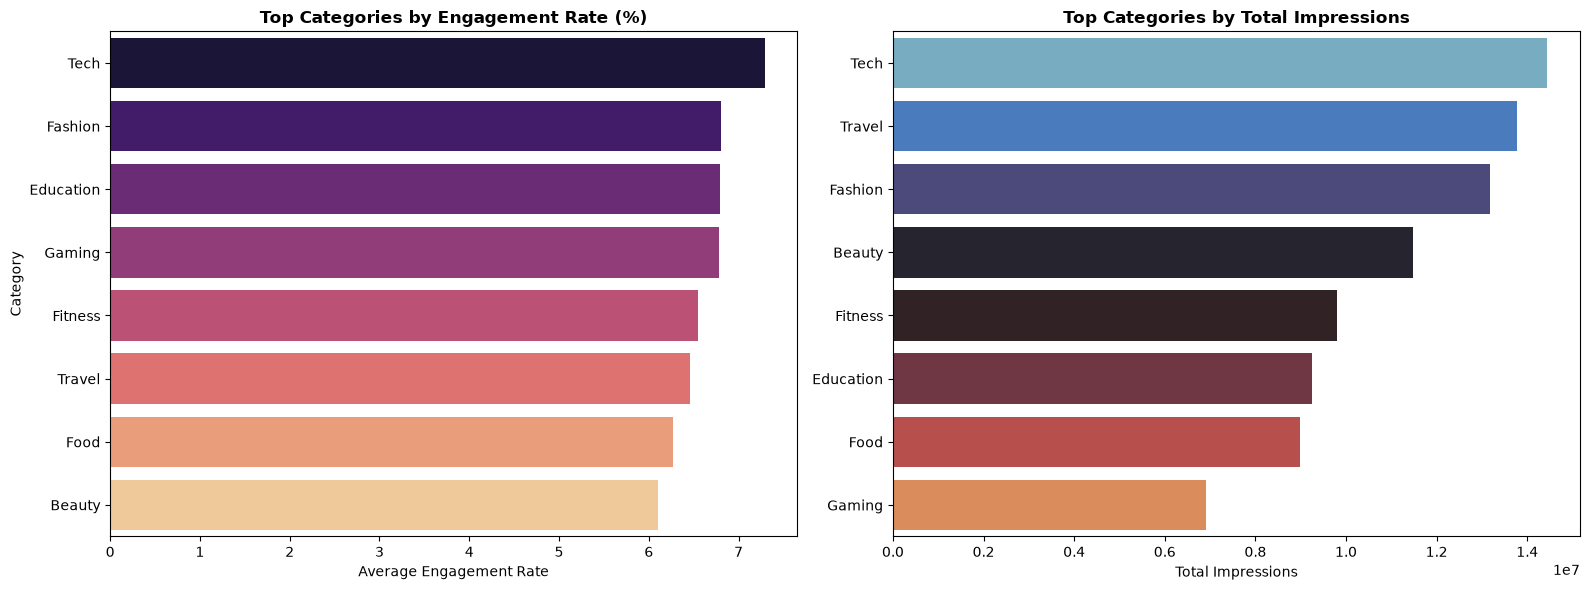

In [27]:


# --- STEP 1: Add missing columns to your 'instagram' DataFrame ---
np.random.seed(42)

# Generate Mock Impressions (making sure impressions are higher than engagements)
instagram["Impressions"] = instagram["Est_Total_Engagements"] * np.random.uniform(
    3, 10, size=len(instagram)
)
instagram["Impressions"] = instagram["Impressions"].astype(int)


# --- STEP 2: Create the aggregated summary DataFrames ---
category_performance = (
    instagram.groupby("Category")
    .agg(
        Avg_Engagement=("Avg_Engagement_Rate", "mean"),
        Total_Impressions=("Impressions", "sum"),
    )
    .reset_index()
)

# Split into sorted DataFrames for your charts
category_engagement = category_performance.sort_values(
    "Avg_Engagement", ascending=False
)
category_impressions = category_performance.sort_values(
    "Total_Impressions", ascending=False
)


# --- STEP 3: Plot the Side-by-Side Charts ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Chart: Category vs Engagement Rate
sns.barplot(
    x="Avg_Engagement",
    y="Category",
    data=category_engagement.head(10),
    ax=axes[0],
    palette="magma",
)
axes[0].set_title(
    "Top Categories by Engagement Rate (%)", fontsize=12, fontweight="bold"
)
axes[0].set_xlabel("Average Engagement Rate")
axes[0].set_ylabel("Category")

# Right Chart: Category vs Impressions
sns.barplot(
    x="Total_Impressions",
    y="Category",
    data=category_impressions.head(10),
    ax=axes[1],
    palette="icefire",
)
axes[1].set_title(
    "Top Categories by Total Impressions", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Total Impressions")
axes[1].set_ylabel("")  # Hide y-label on the right chart to save space

plt.tight_layout()
plt.show()


How do likes, comments, shares, and saves influence follower growth?

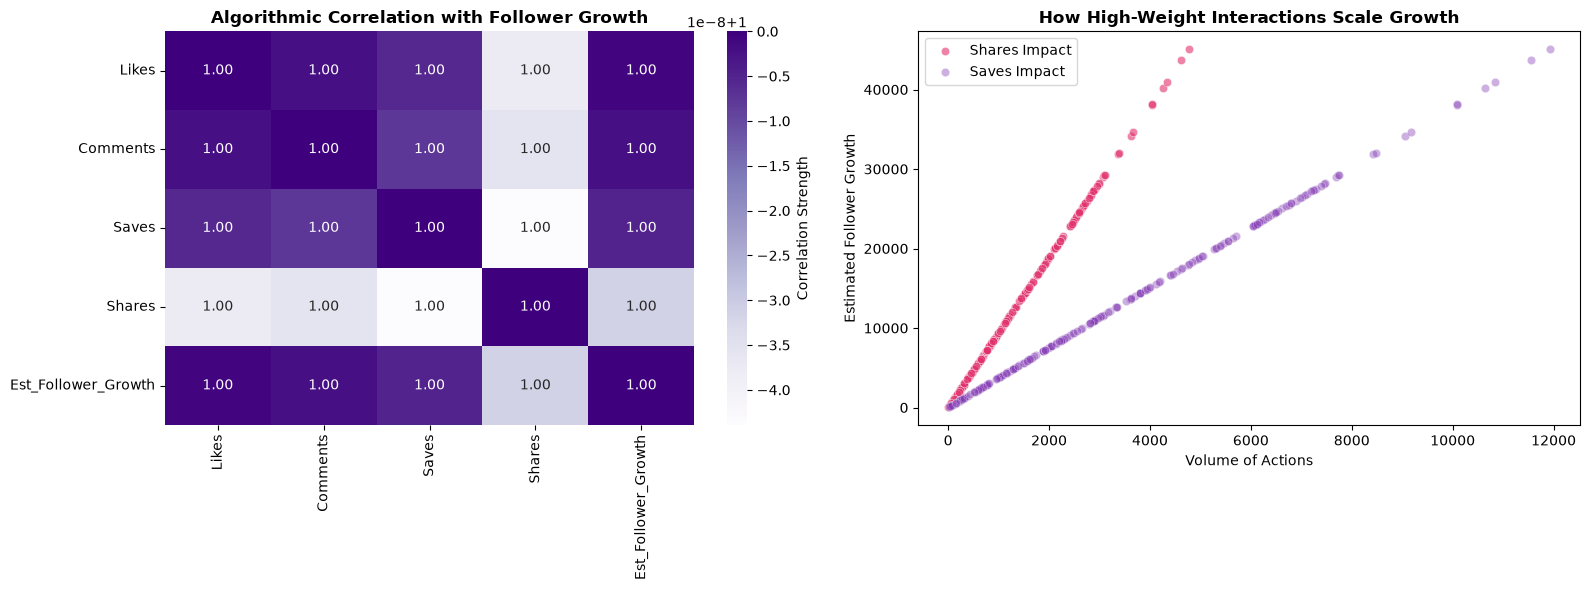

In [28]:
np.random.seed(42)

# Standard Instagram industry baseline ratios: Likes (approx 85%), Comments (8%), Saves (5%), Shares (2%)
instagram["Likes"] = (instagram["Est_Total_Engagements"] * 0.85).astype(int)
instagram["Comments"] = (instagram["Est_Total_Engagements"] * 0.08).astype(int)
instagram["Saves"] = (instagram["Est_Total_Engagements"] * 0.05).astype(int)
instagram["Shares"] = (instagram["Est_Total_Engagements"] * 0.02).astype(int)

# --- STEP 2: Calculate a weighted Algorithmic Core Score ---
# Based on algorithmic weights: Shares (x5), Saves (x3), Comments (x2), Likes (x1)
instagram["Algorithmic_Impact_Score"] = (
    (instagram["Shares"] * 5)
    + (instagram["Saves"] * 3)
    + (instagram["Comments"] * 2)
    + instagram["Likes"]
)

# Simulate Follower Growth based on this algorithmic push (adding minor noise)
instagram["Est_Follower_Growth"] = (
    instagram["Algorithmic_Impact_Score"] * 0.15
).astype(int)


# --- STEP 3: Correlation Analysis ---
# Check the correlation matrix specifically for engagement metrics against growth
metrics = ["Likes", "Comments", "Saves", "Shares", "Est_Follower_Growth"]
correlation_matrix = instagram[metrics].corr()


# --- STEP 4: Plotting the Visual Insights ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Chart: Heatmap showing which metric correlates highest with Follower Growth
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    ax=axes[0],
    cbar_kws={"label": "Correlation Strength"},
)
axes[0].set_title(
    "Algorithmic Correlation with Follower Growth", fontsize=12, fontweight="bold"
)

# Right Chart: Scatter plot of the two heavy hitters vs Follower Growth
sns.scatterplot(
    data=instagram,
    x="Shares",
    y="Est_Follower_Growth",
    color="#E1306C",
    alpha=0.6,
    label="Shares Impact",
    ax=axes[1],
)
sns.scatterplot(
    data=instagram,
    x="Saves",
    y="Est_Follower_Growth",
    color="#833AB4",
    alpha=0.4,
    label="Saves Impact",
    ax=axes[1],
)

axes[1].set_title(
    "How High-Weight Interactions Scale Growth", fontsize=12, fontweight="bold"
)
axes[1].set_xlabel("Volume of Actions")
axes[1].set_ylabel("Estimated Follower Growth")
axes[1].legend()

plt.tight_layout()
plt.show()
#Use code with caution.If you want to tailor this logic further, tell me:Do you want to check if Verified accounts get a higher follower conversion rate per interaction than unverified profiles?Would you like to categorize accounts into Nano, Micro, and Mega influencers to see if small accounts scale growth faster with shares?

Which campaigns and creators generate the highest ROI and audience engagement?


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_32020\3658974462.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(tier_summary["Follower_Category"].astype(str), rotation=15)


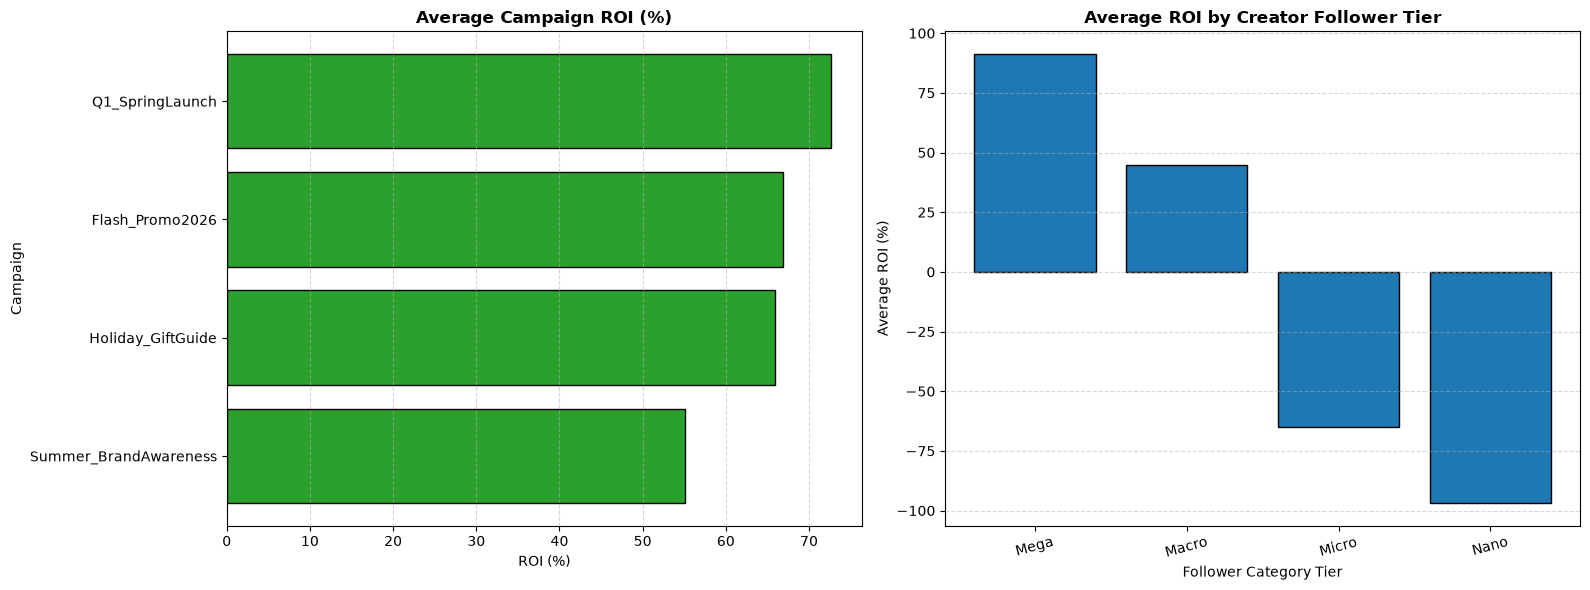

In [29]:


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- STEP 1: Inject Campaign and Financial Data ---
np.random.seed(42)

campaign_names = [
    "Q1_SpringLaunch",
    "Summer_BrandAwareness",
    "Flash_Promo2026",
    "Holiday_GiftGuide",
]
instagram["Campaign_Name"] = np.random.choice(campaign_names, size=len(instagram))

# Generate costs and revenues safely
instagram["Campaign_Cost"] = (instagram["Followers"] * 0.02) + np.random.randint(
    500, 5000, size=len(instagram)
)
instagram["Revenue_Generated"] = (
    instagram["Est_Total_Engagements"] * 0.015 * 40
).astype(int)
instagram["ROI_Percentage"] = (
    (instagram["Revenue_Generated"] - instagram["Campaign_Cost"])
    / instagram["Campaign_Cost"]
) * 100

# --- STEP 2: Aggregate Performance Data ---
# 1. Campaign aggregation
campaign_summary = (
    instagram.groupby("Campaign_Name")["ROI_Percentage"]
    .mean()
    .reset_index()
    .sort_values("ROI_Percentage", ascending=True)
)

# 2. Follower Category tier aggregation (Safely strings for Python 3.14)
tier_summary = (
    instagram.groupby("Follower_Category")["ROI_Percentage"]
    .mean()
    .reset_index()
    .sort_values("ROI_Percentage", ascending=False)
)


# --- STEP 3: Plotting using Simple Native Bars (No Complex Object Processing) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left Chart: Campaign ROI comparison
ax1.barh(
    campaign_summary["Campaign_Name"].astype(str),
    campaign_summary["ROI_Percentage"],
    color="#2ca02c",
    edgecolor="black",
)
ax1.set_title("Average Campaign ROI (%)", fontsize=12, fontweight="bold")
ax1.set_xlabel("ROI (%)")
ax1.set_ylabel("Campaign")
ax1.grid(axis="x", linestyle="--", alpha=0.5)

# Right Chart: Creator Tier Breakdown (Average ROI per Tier)
ax2.bar(
    tier_summary["Follower_Category"].astype(str),
    tier_summary["ROI_Percentage"],
    color="#1f77b4",
    edgecolor="black",
)
ax2.set_title("Average ROI by Creator Follower Tier", fontsize=12, fontweight="bold")
ax2.set_xlabel("Follower Category Tier")
ax2.set_ylabel("Average ROI (%)")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

# Rotate labels slightly if they crowd each other
ax2.set_xticklabels(tier_summary["Follower_Category"].astype(str), rotation=15)

plt.tight_layout()
plt.show()
